# Task 2 — Neural Network for MNIST Digit Classification
**Candidate:** Saran Mathesh  
**Goal:** Classify grayscale handwritten digit images into classes 0–9 using a simple dense neural network, then compare it with a modified architecture.

Run all cells from top to bottom. TensorFlow/Keras downloads MNIST automatically on first use.

## 1. Imports and reproducibility

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Dataset understanding
MNIST contains 70,000 grayscale images of handwritten digits: 60,000 training examples and 10,000 test examples. Each image is 28×28 pixels. Labels are integers 0 through 9, representing the digit shown.

In [19]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Train images:", x_train_full.shape, "Train labels:", y_train_full.shape)
print("Test images:", x_test.shape, "Test labels:", y_test.shape)
print("Pixel range before normalization:", x_train_full.min(), "to", x_train_full.max())
print("Classes:", np.unique(y_train_full))

Train images: (60000, 28, 28) Train labels: (60000,)
Test images: (10000, 28, 28) Test labels: (10000,)
Pixel range before normalization: 0 to 255
Classes: [0 1 2 3 4 5 6 7 8 9]


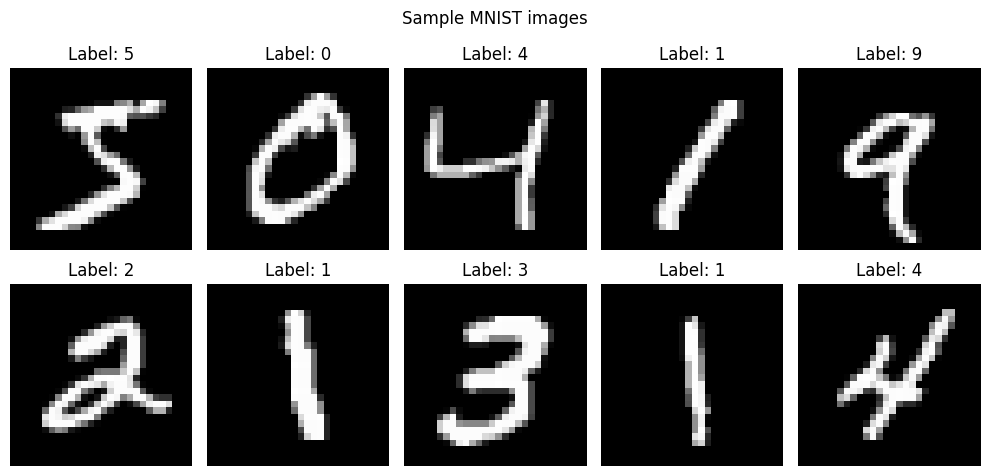

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_full[i], cmap="gray")
    ax.set_title(f"Label: {y_train_full[i]}")
    ax.axis("off")
plt.suptitle("Sample MNIST images")
plt.tight_layout()
plt.show()

## 3. Preprocessing
Pixel intensities are divided by 255 to map them from `[0, 255]` to `[0, 1]`, which improves numerical conditioning during optimization. Dense layers require a one-dimensional input, so each 28×28 image is flattened to 784 values. The official test set remains untouched during model selection; a validation subset is taken from the training data.

In [21]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train_full.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

# Fixed validation split: first 5,000 training examples; remaining 55,000 for fitting.
x_val, y_val = x_train[55000:], y_train_full[55000:]
x_fit, y_fit = x_train[:55000], y_train_full[:55000]

print("Flattened training:", x_fit.shape)
print("Validation:", x_val.shape, "Test:", x_test_flat.shape)
print("Normalized pixel range:", x_fit.min(), "to", x_fit.max())

Flattened training: (55000, 784)
Validation: (5000, 784) Test: (10000, 784)
Normalized pixel range: 0.0 to 1.0


## 4. Model architecture
The baseline is a dense network with one hidden layer of 128 units and ReLU activation. The output layer has 10 Softmax units, one per digit class. Softmax converts output logits into class probabilities that sum to one. Sparse categorical cross-entropy is appropriate because labels are integer class IDs rather than one-hot vectors.

In [22]:
def build_model(hidden_units=128, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(hidden_units, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_model(hidden_units=128)
baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train baseline model

In [23]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_base = baseline_model.fit(
    x_fit, y_fit,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8950 - loss: 0.3846 - val_accuracy: 0.9572 - val_loss: 0.1671
Epoch 2/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9482 - loss: 0.1797 - val_accuracy: 0.9678 - val_loss: 0.1226
Epoch 3/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9630 - loss: 0.1289 - val_accuracy: 0.9734 - val_loss: 0.1025
Epoch 4/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9725 - loss: 0.0991 - val_accuracy: 0.9752 - val_loss: 0.0921
Epoch 5/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0792 - val_accuracy: 0.9758 - val_loss: 0.0859
Epoch 6/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9822 - loss: 0.0646 - val_accuracy: 0.9770 - val_loss: 0.0825
Epoch 7/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9853 - loss: 0.0534 - val_accuracy: 0.9776 - val_loss: 0.0801
Epoch 8/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9882 - loss: 0.0447 - val_accuracy: 0.

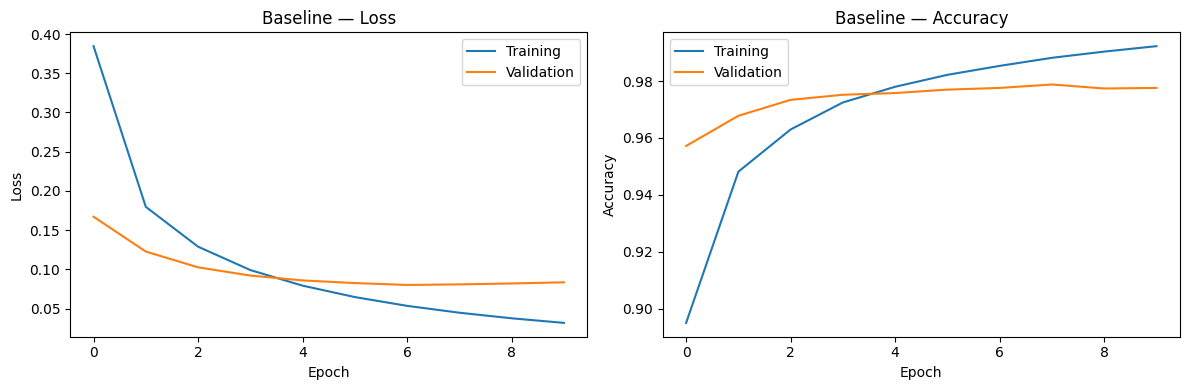

In [24]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Training")
    axes[0].plot(history.history["val_loss"], label="Validation")
    axes[0].set(title=f"{title} — Loss", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="Training")
    axes[1].plot(history.history["val_accuracy"], label="Validation")
    axes[1].set(title=f"{title} — Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_base, "Baseline")

## 6. Baseline evaluation
The confusion matrix compares true classes (rows) with predicted classes (columns). Correct classifications appear on the diagonal; off-diagonal counts show which digits are confused.

Baseline test loss: 0.0833
Baseline test accuracy: 97.5600%
              precision    recall  f1-score   support

           0     0.9701    0.9918    0.9808       980
           1     0.9860    0.9894    0.9877      1135
           2     0.9795    0.9729    0.9762      1032
           3     0.9695    0.9772    0.9734      1010
           4     0.9777    0.9827    0.9802       982
           5     0.9678    0.9776    0.9727       892
           6     0.9841    0.9697    0.9769       958
           7     0.9840    0.9601    0.9719      1028
           8     0.9720    0.9630    0.9675       974
           9     0.9636    0.9703    0.9669      1009

    accuracy                         0.9756     10000
   macro avg     0.9754    0.9755    0.9754     10000
weighted avg     0.9757    0.9756    0.9756     10000



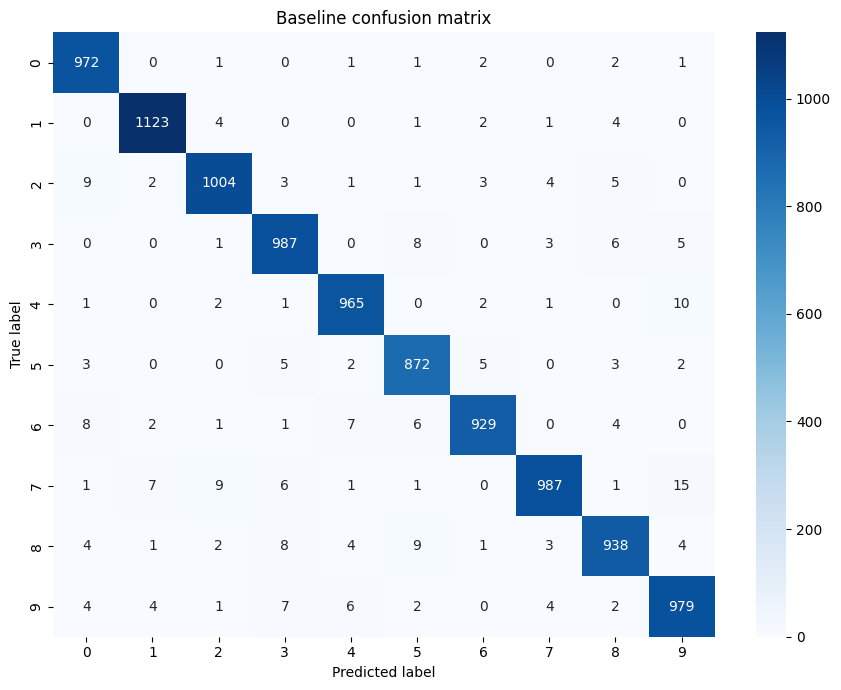

In [25]:
base_test_loss, base_test_acc = baseline_model.evaluate(x_test_flat, y_test, verbose=0)
base_probs = baseline_model.predict(x_test_flat, verbose=0)
base_pred = np.argmax(base_probs, axis=1)
base_cm = confusion_matrix(y_test, base_pred)

print(f"Baseline test loss: {base_test_loss:.4f}")
print(f"Baseline test accuracy: {base_test_acc:.4%}")
print(classification_report(y_test, base_pred, digits=4))

plt.figure(figsize=(9, 7))
sns.heatmap(base_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## 7. Experiment — increase hidden units and add a second hidden layer
We change the network from one 128-unit hidden layer to two hidden layers (256 and 128 units). Other training settings remain the same to make the architecture comparison easier to interpret. A larger network can learn more complex representations, but it also increases computation and may overfit.

In [26]:
def build_modified_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

modified_model = build_modified_model()
modified_model.summary()

history_mod = modified_model.fit(
    x_fit, y_fit,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9164 - loss: 0.2884 - val_accuracy: 0.9714 - val_loss: 0.1117
Epoch 2/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9673 - loss: 0.1095 - val_accuracy: 0.9764 - val_loss: 0.0842
Epoch 3/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9795 - loss: 0.0705 - val_accuracy: 0.9784 - val_loss: 0.0797
Epoch 4/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9851 - loss: 0.0498 - val_accuracy: 0.9786 - val_loss: 0.0757
Epoch 5/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9897 - loss: 0.0353 - val_accuracy: 0.9786 - val_loss: 0.0843
Epoch 6/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9922 - loss: 0.0271 - val_accuracy: 0.9794 - val_loss: 0.0820
Epoch 7/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9934 - loss: 0.0222 - val_accuracy: 0.9786 - val_loss: 0.0868


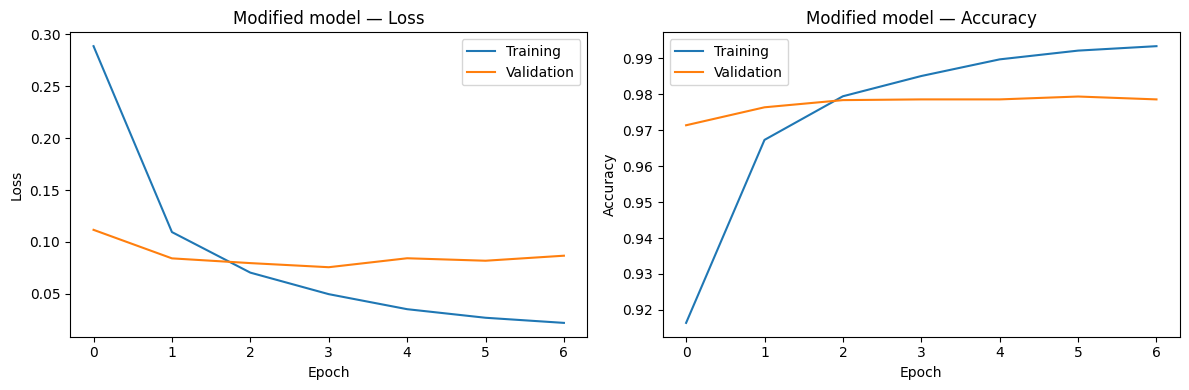

Modified test loss: 0.0770
Modified test accuracy: 97.4800%
              precision    recall  f1-score   support

           0     0.9828    0.9898    0.9863       980
           1     0.9947    0.9885    0.9916      1135
           2     0.9813    0.9661    0.9736      1032
           3     0.9577    0.9851    0.9712      1010
           4     0.9825    0.9715    0.9770       982
           5     0.9686    0.9697    0.9692       892
           6     0.9862    0.9687    0.9774       958
           7     0.9763    0.9630    0.9696      1028
           8     0.9672    0.9682    0.9677       974
           9     0.9498    0.9752    0.9623      1009

    accuracy                         0.9748     10000
   macro avg     0.9747    0.9746    0.9746     10000
weighted avg     0.9750    0.9748    0.9748     10000



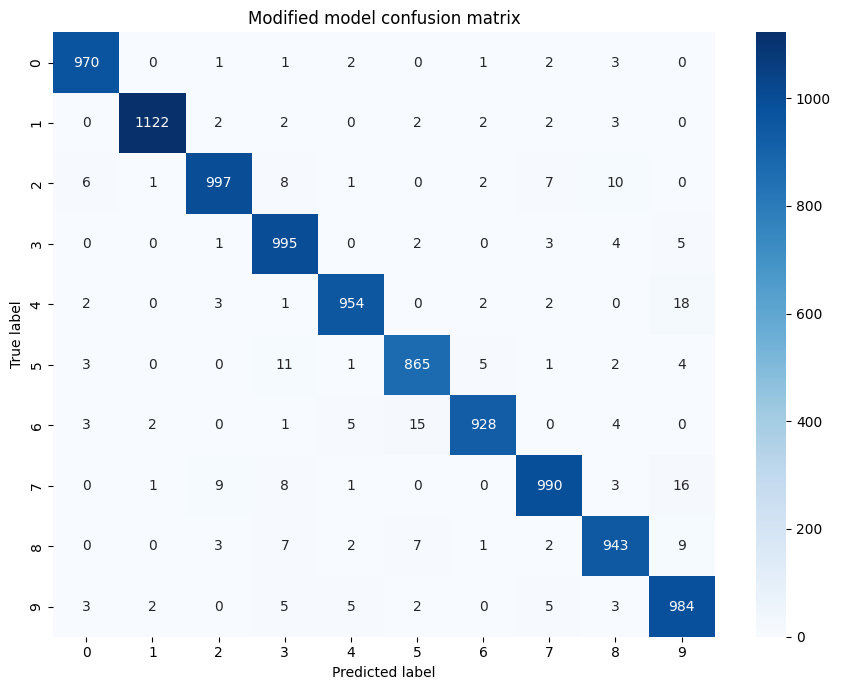

In [27]:
plot_history(history_mod, "Modified model")

mod_test_loss, mod_test_acc = modified_model.evaluate(x_test_flat, y_test, verbose=0)
mod_probs = modified_model.predict(x_test_flat, verbose=0)
mod_pred = np.argmax(mod_probs, axis=1)
mod_cm = confusion_matrix(y_test, mod_pred)

comparison = pd.DataFrame if False else None
print(f"Modified test loss: {mod_test_loss:.4f}")
print(f"Modified test accuracy: {mod_test_acc:.4%}")
print(classification_report(y_test, mod_pred, digits=4))

plt.figure(figsize=(9, 7))
sns.heatmap(mod_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Modified model confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## 8. Compare models

In [28]:
import pandas as pd

comparison = pd.DataFrame([
    {"Model": "Baseline: Dense(128)", "Test loss": base_test_loss, "Test accuracy": base_test_acc,
     "Best validation accuracy": max(history_base.history["val_accuracy"])},
    {"Model": "Modified: Dense(256, 128)", "Test loss": mod_test_loss, "Test accuracy": mod_test_acc,
     "Best validation accuracy": max(history_mod.history["val_accuracy"])}
]).set_index("Model")
display(comparison.round(4))

,Test loss,Test accuracy,Best validation accuracy
Model,,,
Baseline: Dense(128),0.0833,0.9756,0.9788
"Modified: Dense(256, 128)",0.0770,0.9748,0.9794


## 9. Inspect misclassified examples

Misclassified test examples: 252


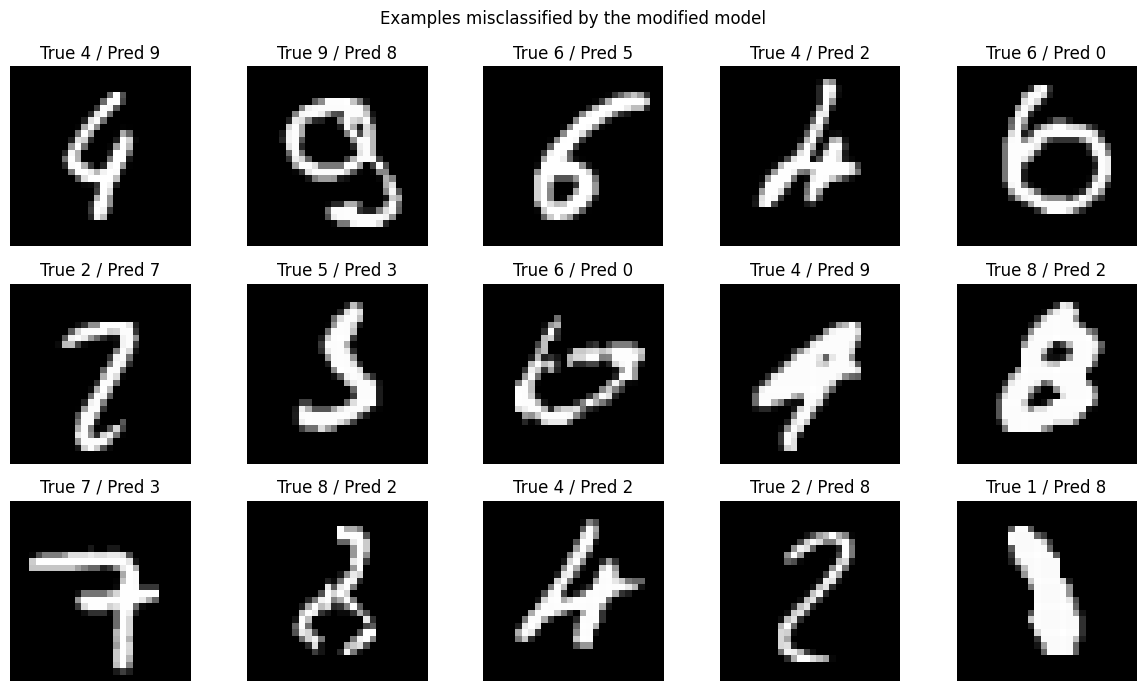

In [29]:
wrong = np.where(mod_pred != y_test)[0]
print("Misclassified test examples:", len(wrong))
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax, idx in zip(axes.flat, wrong[:15]):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"True {y_test[idx]} / Pred {mod_pred[idx]}")
    ax.axis("off")
plt.suptitle("Examples misclassified by the modified model")
plt.tight_layout()
plt.show()

## 10. Findings, limitations, and next steps
Complete this section using the actual output produced by your run.

### Findings
1. Report baseline test accuracy and loss.
2. Report modified-model test accuracy and loss.
3. State whether the deeper/larger model improved test accuracy and by how many percentage points.
4. Identify digit pairs that are commonly confused using the confusion matrix.
5. Compare training and validation curves for evidence of overfitting.
6. Mention whether the model's mistakes tend to involve visually similar handwriting.

### Limitations
- Flattening discards the 2D spatial structure of images.
- A dense network may be less effective than a convolutional neural network (CNN) for image recognition.
- Results can vary slightly with initialization and training settings.

### Possible improvement
Compare the dense model with a small CNN using convolution and pooling layers, while keeping a validation set for model selection.

## 11. Save trained models

In [30]:
baseline_model.save("mnist_baseline.keras")
modified_model.save("mnist_modified.keras")
print("Saved mnist_baseline.keras and mnist_modified.keras")

Saved mnist_baseline.keras and mnist_modified.keras
